In [1]:
"""
# 📊 보행 임베딩 비교 분석 노트북
`scripts/build_embeddings.py`로 생성된 임베딩 결과를 시각화하고 성능을 비교합니다.

## 먼저 아래 명령 중 원하는 것을 실행하세요
```bash
# CNN + Master 데이터
python scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model cnn

# CNN + Raw 데이터
python scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model cnn

# AutoEncoder 실행
python scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model ae; python scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model ae;  python scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model centroid; python scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model centroid



# Centroid 실행
python scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model centroid
```
"""

'\n# 📊 보행 임베딩 비교 분석 노트북\n`scripts/build_embeddings.py`로 생성된 임베딩 결과를 시각화하고 성능을 비교합니다.\n\n## 먼저 아래 명령 중 원하는 것을 실행하세요\n```bash\n# CNN + Master 데이터\npython scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model cnn\n\n# CNN + Raw 데이터\npython scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model cnn\n\n# AutoEncoder 실행\npython scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model ae; python scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model ae;  python scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model centroid; python scripts/build_embeddings.py --input_path data/processed/raw_merged.parquet --model centroid\n\n\n\n# Centroid 실행\npython scripts/build_embeddings.py --input_path data/processed/Master_Gait_Dataset.parquet --model centroid\n```\n'

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score

# 경로 설정
NOTEBOOK_DIR = Path(".").resolve()
ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = ROOT / "data" / "processed"

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(f"ROOT: {ROOT}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")


ROOT: C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking
PROCESSED_DIR: C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\data\processed


In [3]:
def find_embedding_files():
    return sorted(PROCESSED_DIR.glob("embedding_results_*.parquet"))

files = find_embedding_files()
print(f"발견된 임베딩 결과 파일: {len(files)}개")
for f in files:
    print(f"  - {f.name}")


발견된 임베딩 결과 파일: 9개
  - embedding_results_ae_Master_Gait_Dataset.parquet
  - embedding_results_ae_Master_Gait_Dataset_lower.parquet
  - embedding_results_ae_raw_merged.parquet
  - embedding_results_centroid_Master_Gait_Dataset.parquet
  - embedding_results_centroid_Master_Gait_Dataset_lower.parquet
  - embedding_results_centroid_raw_merged.parquet
  - embedding_results_cnn_Master_Gait_Dataset.parquet
  - embedding_results_cnn_Master_Gait_Dataset_lower.parquet
  - embedding_results_cnn_raw_merged.parquet


In [4]:
def load_embedding(file_path):
    df = pd.read_parquet(file_path)
    print(f"✅ {file_path.name}")
    print(f"   {df.shape[0]}개 Trial | 그룹 분포: {df['group'].value_counts().to_dict()}")
    return df


In [5]:
GROUP_STYLE = {
    "ACLD":                {"color": "#E63946", "marker": "o"},
    "ACLR":                {"color": "#F4A261", "marker": "s"},
    "Healthy adults":      {"color": "#2A9D8F", "marker": "^"},
    "Healthy adolescents": {"color": "#457B9D", "marker": "D"},
}
DEFAULT_STYLE = {"color": "#999999", "marker": "x"}


In [6]:
def plot_embedding(df, title="", ax=None):
    """1개의 임베딩 결과 산점도 및 Silhouette Score 출력"""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 7))

    for group, gdf in df.groupby("group"):
        style = GROUP_STYLE.get(group, DEFAULT_STYLE)
        ax.scatter(gdf["umap_x"], gdf["umap_y"],
                   c=style["color"], marker=style["marker"],
                   label=group, alpha=0.75, s=55,
                   edgecolors="white", linewidths=0.4)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP Dim 1")
    ax.set_ylabel("UMAP Dim 2")
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.2)

    # Silhouette Score
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    if emb_cols:
        groups = df["group"].unique()
        label_map = {g: i for i, g in enumerate(groups)}
        y = np.array([label_map[g] for g in df["group"]])
        X = df[emb_cols].values
        score = silhouette_score(X, y, sample_size=min(1000, len(df)), random_state=42)
        ax.text(0.02, 0.98, f"Silhouette: {score:.3f}",
                transform=ax.transAxes, fontsize=9, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.7))
        if standalone:
            plt.tight_layout()
            save_path = f"../artifacts/embedding_{title.replace(' ', '_')}.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 시각화 결과 저장됨: {save_path}")
            plt.show()
        return score

    if standalone:
        plt.tight_layout()
        plt.show()
    return None


In [7]:
def compare_embeddings(file_a, file_b, label_a="A", label_b="B"):
    """두 임베딩 결과를 나란히 비교 시각화"""
    df_a = load_embedding(Path(file_a))
    df_b = load_embedding(Path(file_b))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("보행 임베딩 결과 비교 분석", fontsize=14, fontweight="bold")

    score_a = plot_embedding(df_a, label_a, ax=axes[0])
    score_b = plot_embedding(df_b, label_b, ax=axes[1])

    plt.tight_layout()
    plt.show()

    if score_a is not None and score_b is not None:
        print(f"\n📊 Silhouette Score 비교 (높을수록 군집 분리 우수)")
        print(f"   {label_a:<40}: {score_a:.4f}")
        print(f"   {label_b:<40}: {score_b:.4f}")
        winner = label_a if score_a >= score_b else label_b
        print(f"   🏆 우승: {winner}")


In [8]:
def plot_subject(df, subject_id):
    """특정 피험자의 Trial들이 UMAP 공간에서 어떻게 분포하는지 확인"""
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(df["umap_x"], df["umap_y"], c="#cccccc", alpha=0.3, s=20, label="Others")

    sub = df[df["subject_id"] == subject_id]
    if sub.empty:
        print(f"'{subject_id}' 데이터 없음")
        return

    ax.scatter(sub["umap_x"], sub["umap_y"],
               c="#E63946", s=120, marker="*",
               edgecolors="black", linewidths=0.5,
               label=f"{subject_id} ({len(sub)} trials)")
    ax.set_title(f"피험자 [{subject_id}] Trial 분포", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


✅ embedding_results_ae_Master_Gait_Dataset.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_ae_Master_Gait_Dataset.png


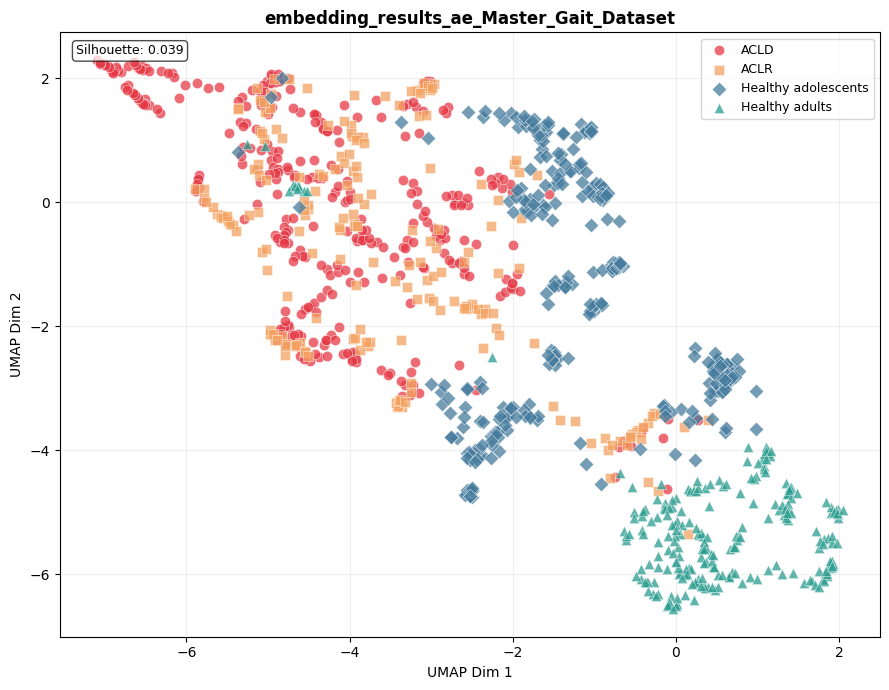

✅ embedding_results_ae_Master_Gait_Dataset_lower.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_ae_Master_Gait_Dataset_lower.png


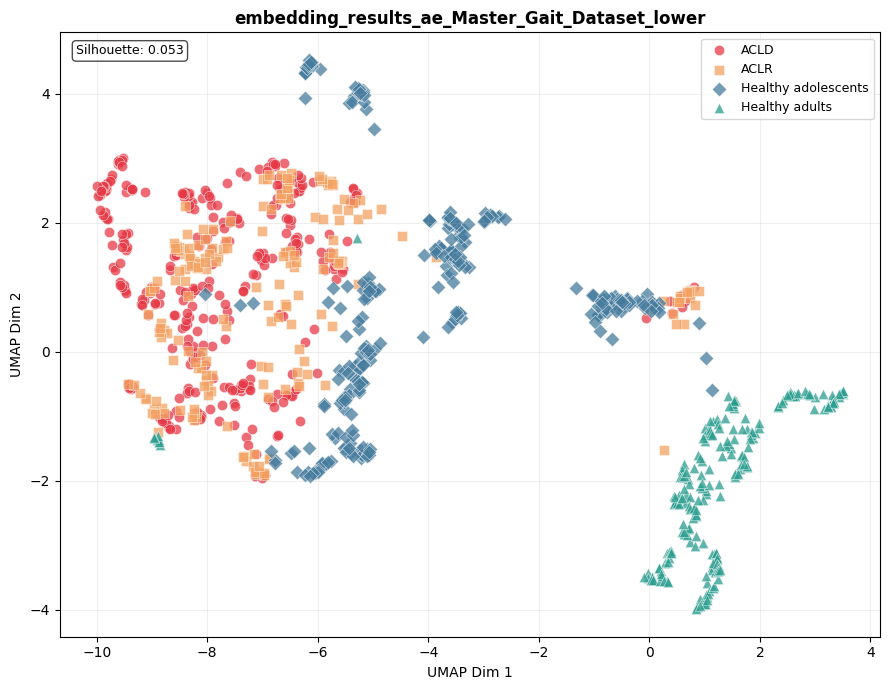

✅ embedding_results_ae_raw_merged.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_ae_raw_merged.png


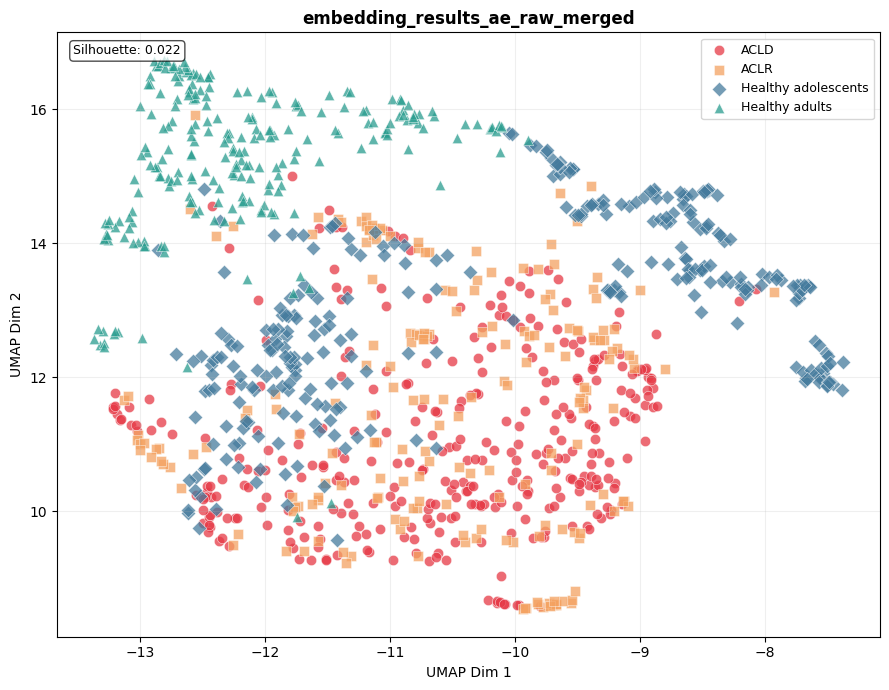

✅ embedding_results_centroid_Master_Gait_Dataset.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_centroid_Master_Gait_Dataset.png


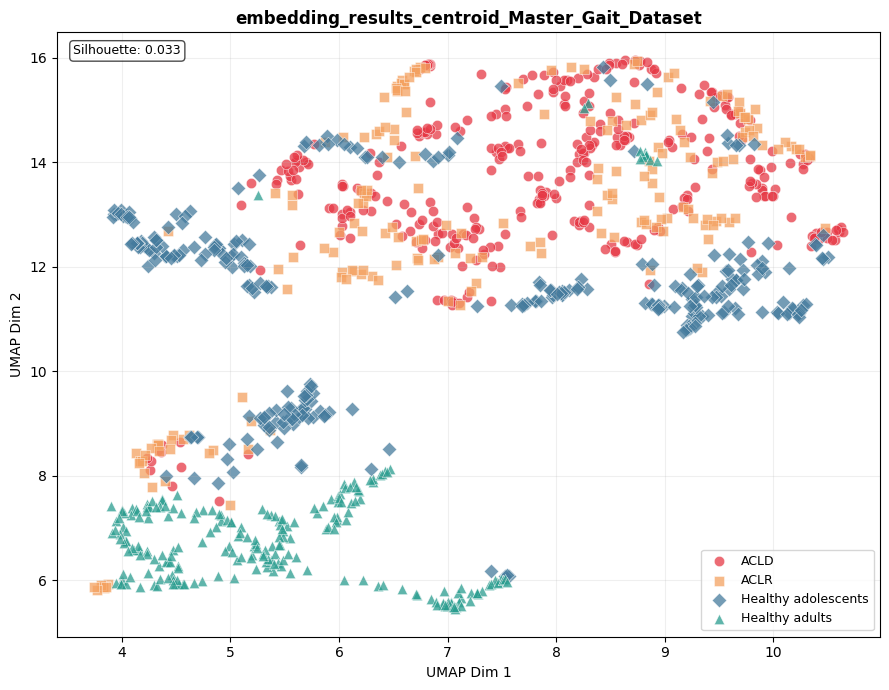

✅ embedding_results_centroid_Master_Gait_Dataset_lower.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_centroid_Master_Gait_Dataset_lower.png


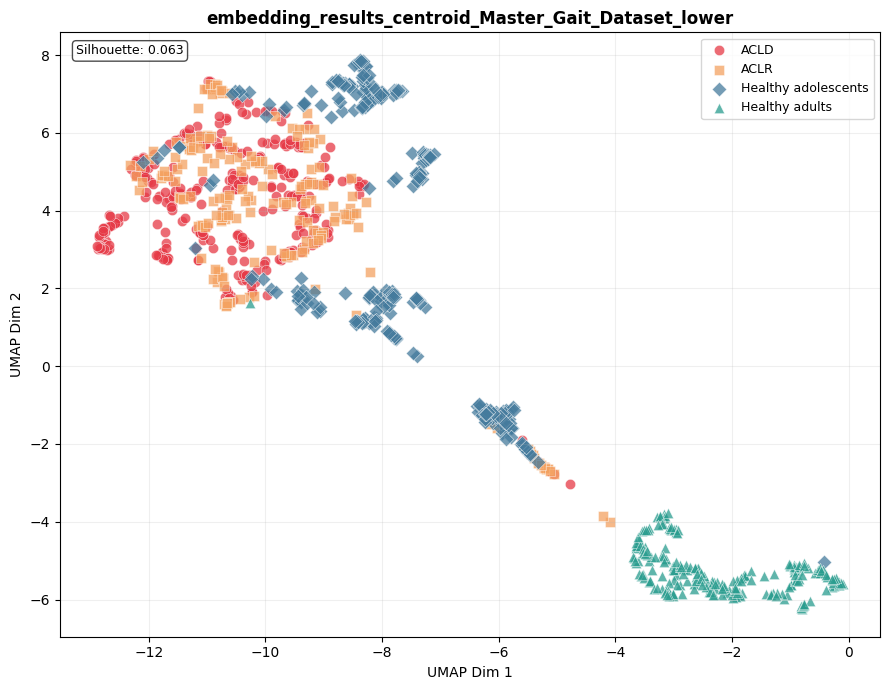

✅ embedding_results_centroid_raw_merged.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_centroid_raw_merged.png


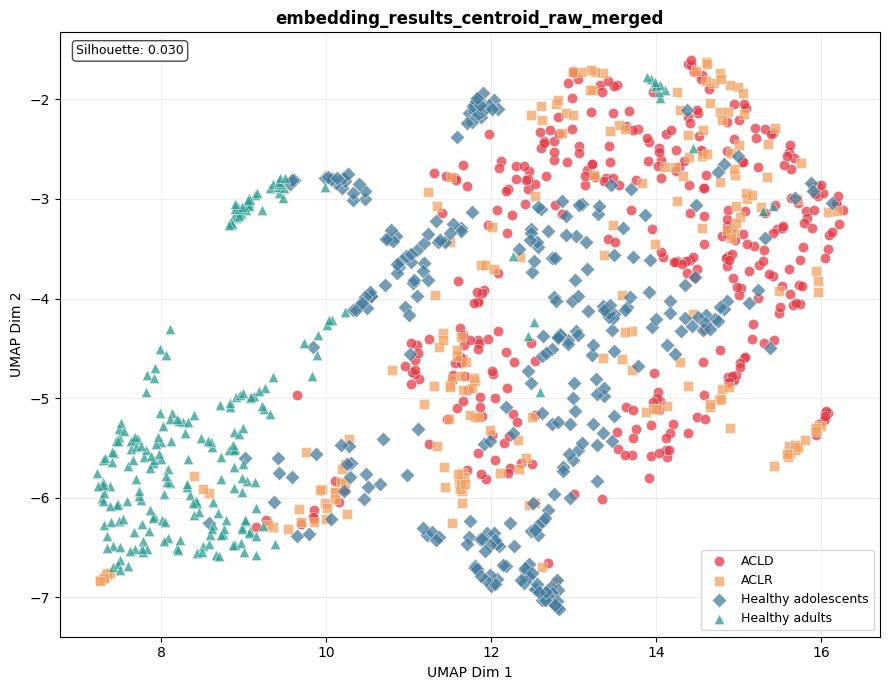

✅ embedding_results_cnn_Master_Gait_Dataset.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_cnn_Master_Gait_Dataset.png


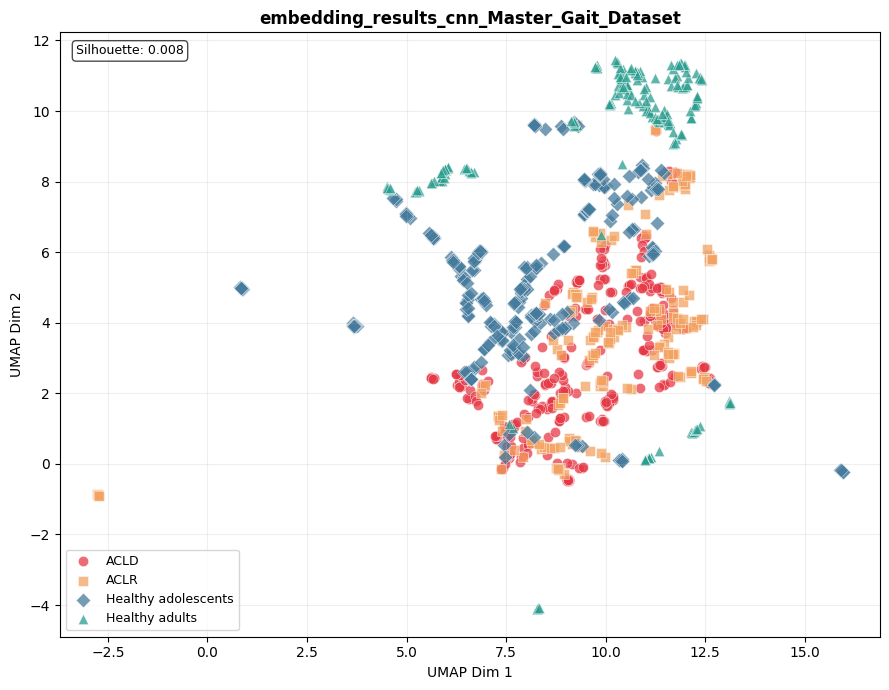

✅ embedding_results_cnn_Master_Gait_Dataset_lower.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_cnn_Master_Gait_Dataset_lower.png


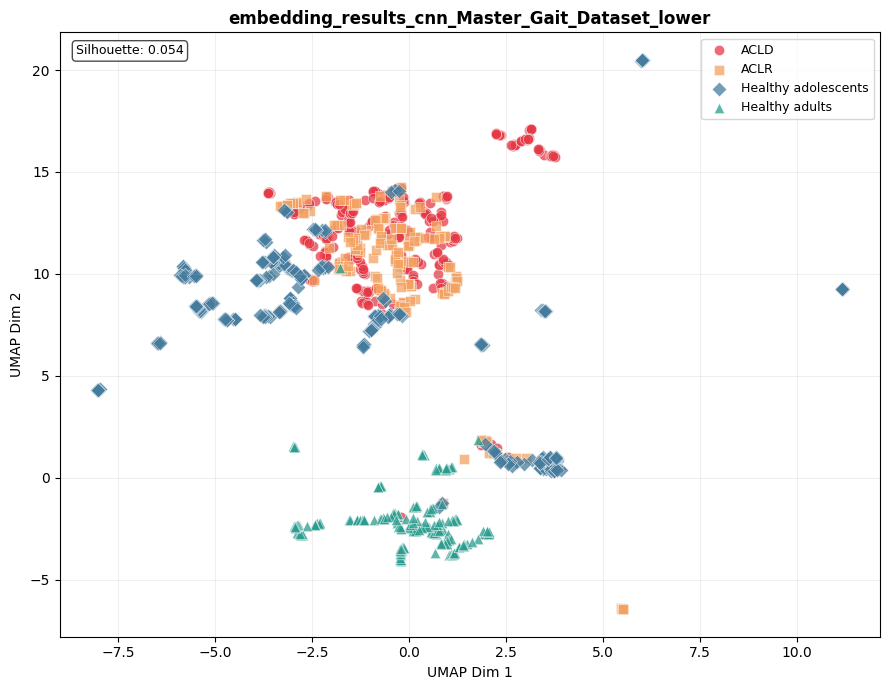

✅ embedding_results_cnn_raw_merged.parquet
   1089개 Trial | 그룹 분포: {'ACLD': 345, 'Healthy adolescents': 304, 'Healthy adults': 238, 'ACLR': 202}
📊 시각화 결과 저장됨: ../artifacts/embedding_embedding_results_cnn_raw_merged.png


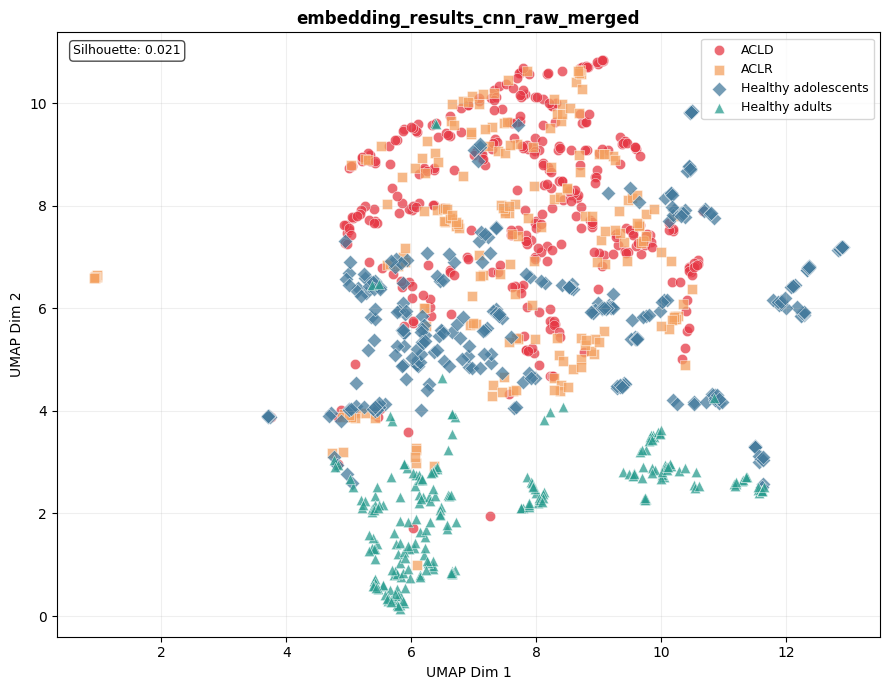

In [9]:
## 🚀 실행 예시

### Master vs Raw 교차 비교
# compare_embeddings(
#     file_a=PROCESSED_DIR / "embedding_results_cnn_Master_Gait_Dataset.parquet",
#     file_b=PROCESSED_DIR / "embedding_results_cnn_raw_merged.parquet",
#     label_a="CNN / Master (315 피처, Feature Selected)",
#     label_b="CNN / Raw (693 피처, 전체)",
# )

import warnings

warnings.filterwarnings("ignore")
### 단일 결과 시각화
for f in files: 
    df = load_embedding(PROCESSED_DIR / f)
    plot_embedding(df, title=Path(f).stem) 




In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def evaluate_clustering(df):
    """임베딩 컬럼 기준으로 군집 평가 지표 3종 계산"""
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    if not emb_cols:
        return None
    groups = df["group"].unique()
    label_map = {g: i for i, g in enumerate(groups)}
    y = [label_map[g] for g in df["group"]]
    X = df[emb_cols].values
    sil = silhouette_score(X, y, sample_size=min(1000, len(X)), random_state=42)
    db  = davies_bouldin_score(X, y)
    ch  = calinski_harabasz_score(X, y)
    return sil, db, ch

rows = []
for f in find_embedding_files():
    df = pd.read_parquet(f)
    result = evaluate_clustering(df)
    if result:
        sil, db, ch = result
        # 파일명에서 모델명/데이터명 파싱
        name = f.stem.replace("embedding_results_", "")
        rows.append({"파일": name, "Silhouette": round(sil, 4),
                     "Davies-Bouldin": round(db, 4),
                     "Calinski-Harabasz": round(ch, 2)})

summary = pd.DataFrame(rows).sort_values("Silhouette", ascending=False)
print("📊 Clustering Evaluation Summary")
display(summary.style.highlight_max(subset=["Silhouette","Calinski-Harabasz"], color="lightgreen")
               .highlight_min(subset=["Davies-Bouldin"], color="lightgreen")
               .hide())  # index 숨기기


📊 Clustering Evaluation Summary


파일,Silhouette,Davies-Bouldin,Calinski-Harabasz
centroid_Master_Gait_Dataset_lower,0.063200,4.481100,68.320000
cnn_Master_Gait_Dataset_lower,0.054200,4.492600,57.790000
ae_Master_Gait_Dataset_lower,0.052600,4.881200,54.750000
ae_Master_Gait_Dataset,0.038900,4.733000,38.260000
centroid_Master_Gait_Dataset,0.032600,4.638300,48.870000
centroid_raw_merged,0.030300,4.864800,39.200000
ae_raw_merged,0.021600,5.408700,28.140000
cnn_raw_merged,0.021100,6.146300,23.060000
cnn_Master_Gait_Dataset,0.008000,4.763100,31.270000
